# Hierarchical Clustering
Using the **Iris Dataset** to demonstrate Hierarchical (Agglomerative) Clustering step by step.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Dataset

In [2]:
# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Actual labels for reference only (NOT used in clustering)
df['actual_species'] = iris.target

print('Shape:', df.shape)
df.head()

Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('Dataset Info:')
print(df.info())
print('\nStatistical Summary:')
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   actual_species     150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Check missing values
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
actual_species       0
dtype: int64


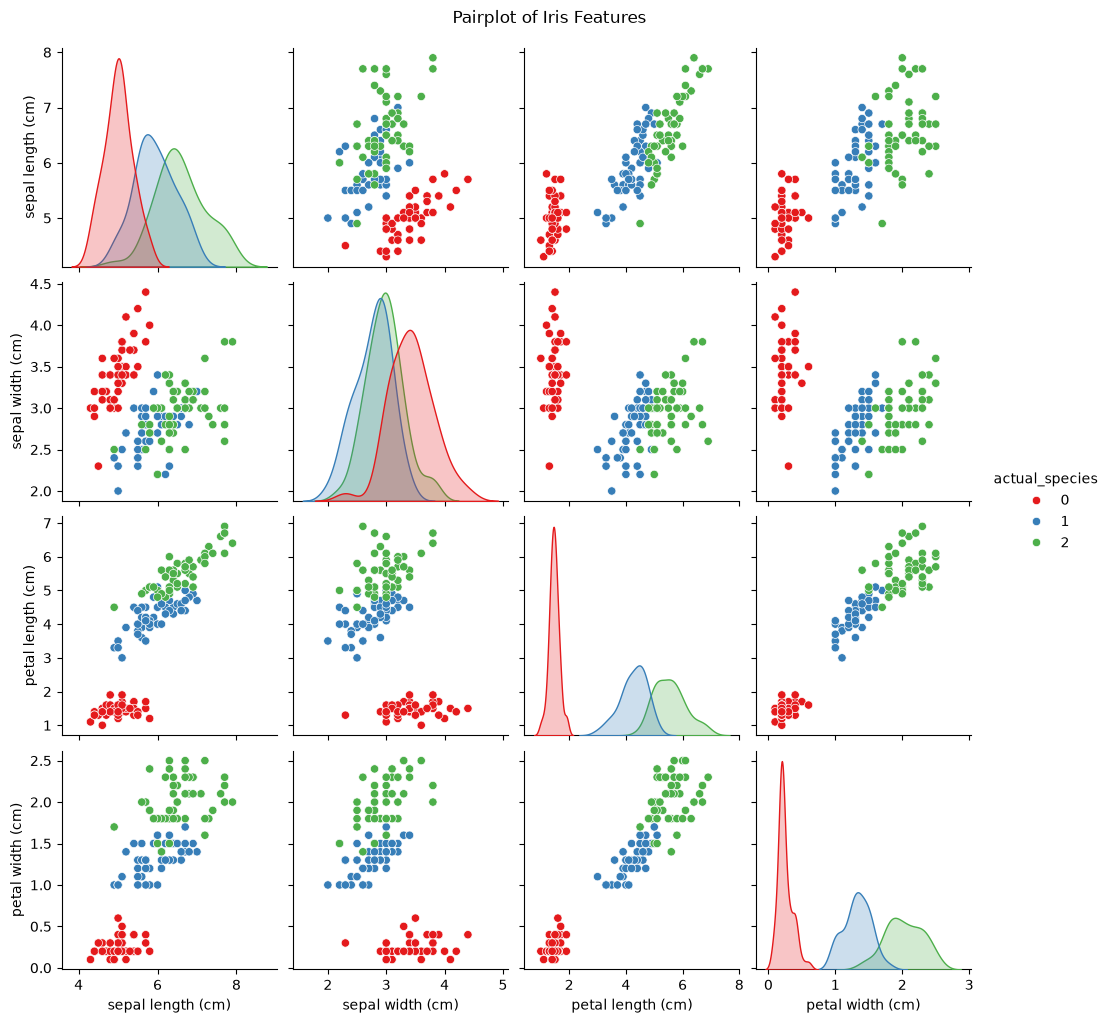

In [5]:
# Pairplot
sns.pairplot(df, hue='actual_species', palette='Set1')
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

## 4. Feature Scaling

In [6]:
# Drop label column, keep only features
X = df.drop('actual_species', axis=1)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled Data Shape:', X_scaled.shape)

Scaled Data Shape: (150, 4)


## 5. Dendrogram — Find Optimal Number of Clusters

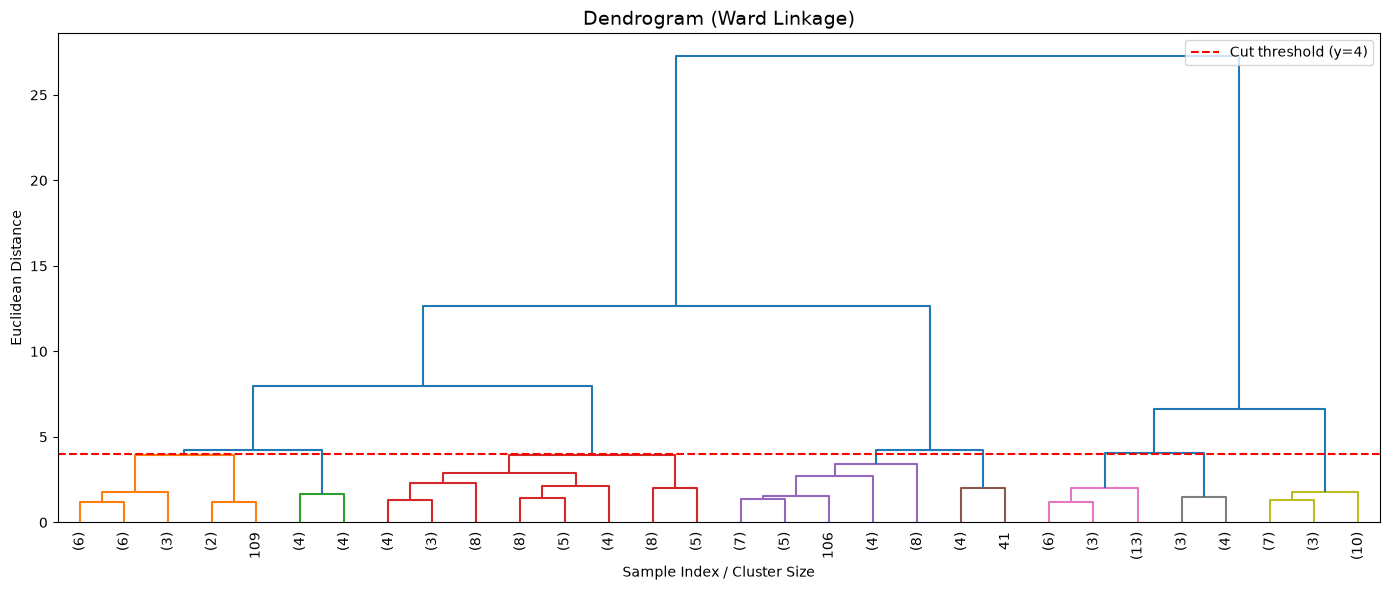

Tip: Cut the dendrogram where the vertical lines are longest (biggest gap) to get optimal clusters.


In [7]:
# Build linkage matrix using Ward method
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    color_threshold=4
)
plt.title('Dendrogram (Ward Linkage)', fontsize=14)
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Euclidean Distance')
plt.axhline(y=4, color='red', linestyle='--', label='Cut threshold (y=4)')
plt.legend()
plt.tight_layout()
plt.show()

print('Tip: Cut the dendrogram where the vertical lines are longest (biggest gap) to get optimal clusters.')

## 6. Silhouette Score — Confirm Best Number of Clusters

K=2  Silhouette Score: 0.5770
K=3  Silhouette Score: 0.4467
K=4  Silhouette Score: 0.4006
K=5  Silhouette Score: 0.3306
K=6  Silhouette Score: 0.3149
K=7  Silhouette Score: 0.3170
K=8  Silhouette Score: 0.3109
K=9  Silhouette Score: 0.3114
K=10  Silhouette Score: 0.3161


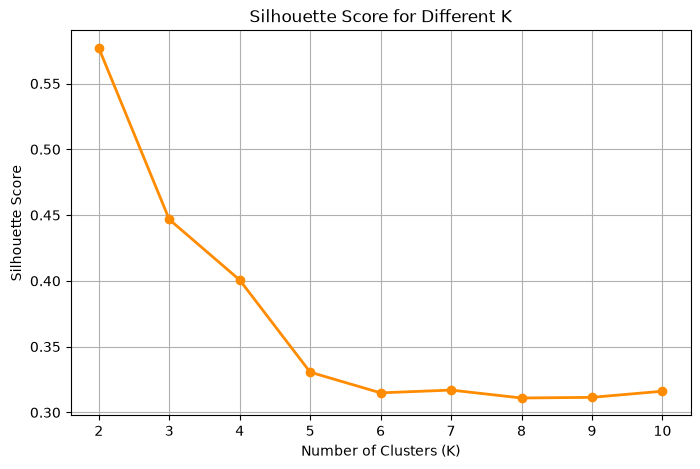


Best K = 2 with Silhouette Score = 0.5770


In [8]:
sil_scores = []

for k in range(2, 11):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f'K={k}  Silhouette Score: {score:.4f}')

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='o', color='darkorange', linewidth=2)
plt.title('Silhouette Score for Different K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

best_k = range(2, 11)[sil_scores.index(max(sil_scores))]
print(f'\nBest K = {best_k} with Silhouette Score = {max(sil_scores):.4f}')

## 7. Compare Different Linkage Methods

In [9]:
linkage_methods = ['ward', 'complete', 'average', 'single']

print(f'Silhouette Scores for K=3 across linkage methods:')
print('-'*40)
for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'{method.capitalize():10} : {score:.4f}')

Silhouette Scores for K=3 across linkage methods:
----------------------------------------
Ward       : 0.4467
Complete   : 0.4496
Average    : 0.4803
Single     : 0.5046


## 8. Train Final Agglomerative Clustering Model (K=3, Ward)

In [10]:
# Final model
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster'] = hc.fit_predict(X_scaled)

print('Cluster Distribution:')
print(df['cluster'].value_counts())

Cluster Distribution:
cluster
0    71
1    49
2    30
Name: count, dtype: int64


## 9. Visualize Clusters using PCA (2D)

In [11]:
# Reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f'Explained Variance Ratio: {pca.explained_variance_ratio_}')
print(f'Total Variance Explained: {sum(pca.explained_variance_ratio_):.2%}')

Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Explained: 95.81%


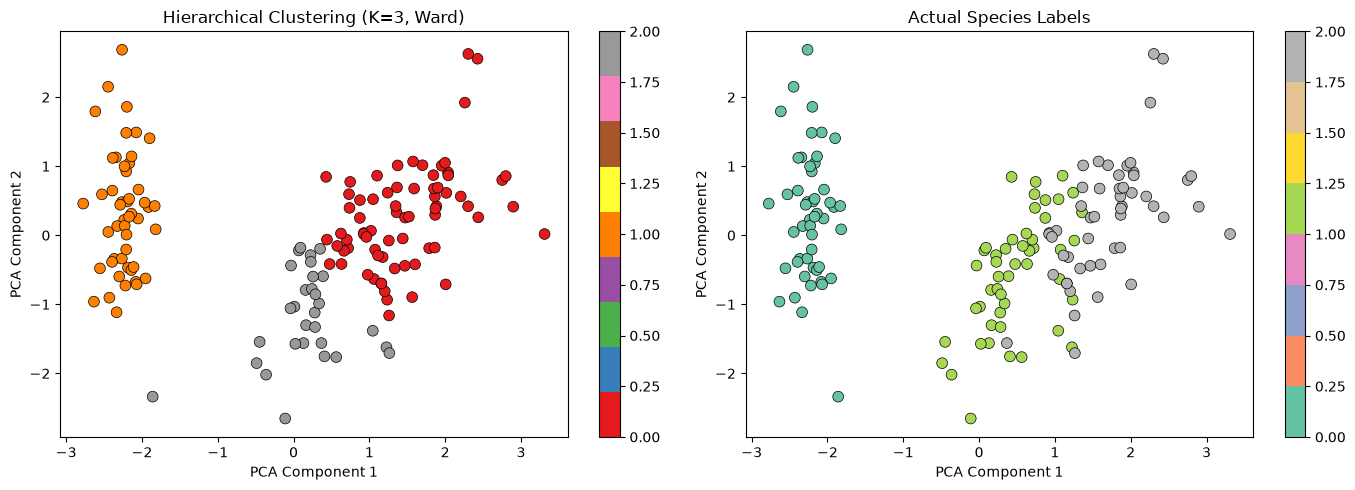

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hierarchical Clusters
scatter1 = axes[0].scatter(df['PCA1'], df['PCA2'], c=df['cluster'],
                            cmap='Set1', s=60, edgecolors='k', linewidths=0.5)
axes[0].set_title('Hierarchical Clustering (K=3, Ward)', fontsize=12)
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(scatter1, ax=axes[0])

# Actual Labels
scatter2 = axes[1].scatter(df['PCA1'], df['PCA2'], c=df['actual_species'],
                            cmap='Set2', s=60, edgecolors='k', linewidths=0.5)
axes[1].set_title('Actual Species Labels', fontsize=12)
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

## 10. Cluster Analysis

In [13]:
# Mean feature values per cluster
cluster_summary = df.groupby('cluster')[iris.feature_names].mean()
print('Cluster Feature Means:')
cluster_summary

Cluster Feature Means:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,6.546479,2.992958,5.267606,1.854930
1,5.016327,3.451020,1.465306,0.244898
2,5.530000,2.566667,3.930000,1.206667


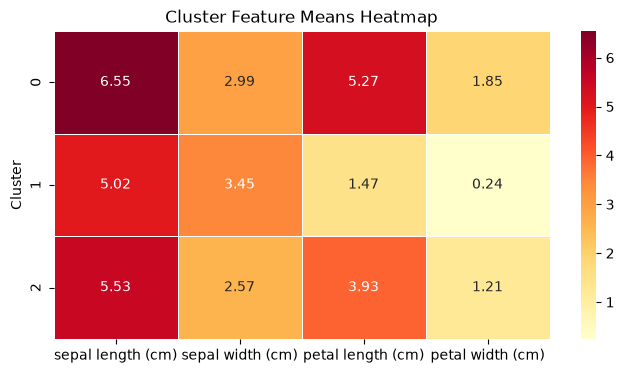

In [14]:
# Heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(cluster_summary, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Feature Means Heatmap')
plt.ylabel('Cluster')
plt.show()

## 11. Hierarchical vs K-Means Comparison

In [15]:
from sklearn.cluster import KMeans

# K-Means for comparison
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

hc_score    = silhouette_score(X_scaled, df['cluster'])
km_score    = silhouette_score(X_scaled, kmeans_labels)

print('='*45)
print('     Algorithm Comparison (K=3)')
print('='*45)
print(f'Hierarchical (Ward)  Silhouette: {hc_score:.4f}')
print(f'K-Means              Silhouette: {km_score:.4f}')
print('='*45)

     Algorithm Comparison (K=3)
Hierarchical (Ward)  Silhouette: 0.4467
K-Means              Silhouette: 0.4599


## 12. Final Evaluation

In [16]:
final_score = silhouette_score(X_scaled, df['cluster'])

print('='*45)
print('   HIERARCHICAL CLUSTERING RESULTS')
print('='*45)
print(f'Algorithm          : Agglomerative')
print(f'Linkage Method     : Ward')
print(f'Number of Clusters : 3')
print(f'Silhouette Score   : {final_score:.4f}')
print('='*45)

   HIERARCHICAL CLUSTERING RESULTS
Algorithm          : Agglomerative
Linkage Method     : Ward
Number of Clusters : 3
Silhouette Score   : 0.4467
